<a href="https://colab.research.google.com/github/zaidkhan8241/Brain-Tumor-MRI-Prediction/blob/main/Brain_Tumor_MRI_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset"
)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: zaid2006
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:08<00:00, 20.1MB/s]


In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential # Standardized import
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from keras.applications import EfficientNetB0

In [ ]:
conv_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
conv_base.trainable = True

for layer in conv_base.layers[:-20]:
    layer.trainable = False

In [ ]:
conv_base.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 1,350,960 (5.15 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

In [ ]:
from tensorflow.keras import Sequential as KSequential # Standardized import, aliased to avoid conflict if `sequential` was used as variable
from keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
model = KSequential()
model.add(conv_base)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.3)),
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
        '/content/brain-tumor-mri-dataset/Training',
        target_size=(224, 224), # Changed to match EfficientNetB0 input
        batch_size=batch_size,
        class_mode='sparse') # Changed from 'binary' to 'sparse' for multi-class integer labels

validation_generator = test_datagen.flow_from_directory(
        '/content/brain-tumor-mri-dataset/Testing',
        target_size=(224, 224), # Changed to match EfficientNetB0 input
        batch_size=batch_size,
        class_mode='sparse') # Changed from 'binary' to 'sparse' for multi-class integer labels

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
conv_base.trainable = False

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 485ms/step - accuracy: 0.7005 - loss: 0.8025 - val_accuracy: 0.7925 - val_loss: 0.6021
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 414ms/step - accuracy: 0.7889 - loss: 0.5350 - val_accuracy: 0.8019 - val_loss: 0.5524
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 406ms/step - accuracy: 0.8205 - loss: 0.4633 - val_accuracy: 0.8406 - val_loss: 0.5072
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 412ms/step - accuracy: 0.8384 - loss: 0.4275 - val_accuracy: 0.8044 - val_loss: 0.5876
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 410ms/step - accuracy: 0.8477 - loss: 0.4039 - val_accuracy: 0.8019 - val_loss: 0.6007
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 397ms/step - accuracy: 0.8575 - loss: 0.3643 - val_accuracy: 0.8450 - val_loss: 0.4583
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 402ms/step - accuracy: 0.8637 - loss: 0.3594 - val_accuracy: 0.8238 - val_loss: 0.5011
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 408ms/step - accuracy: 0.8714 - loss: 

In [ ]:
conv_base.trainable = True

for layer in conv_base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 456ms/step - accuracy: 0.8737 - loss: 0.3508 - val_accuracy: 0.8956 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 418ms/step - accuracy: 0.9191 - loss: 0.2178 - val_accuracy: 0.9050 - val_loss: 0.3251 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 431ms/step - accuracy: 0.9352 - loss: 0.1782 - val_accuracy: 0.9256 - val_loss: 0.2978 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 425ms/step - accuracy: 0.9479 - loss: 0.1417 - val_accuracy: 0.9281 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 417ms/step - accuracy: 0.9591 - loss: 0.1115 - val_accuracy: 0.9219 - val_loss: 0.3931 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 415ms/step - accuracy: 0.9613 - loss: 0.1063 - val_accuracy: 0.9206 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 420ms/step - accuracy: 0.

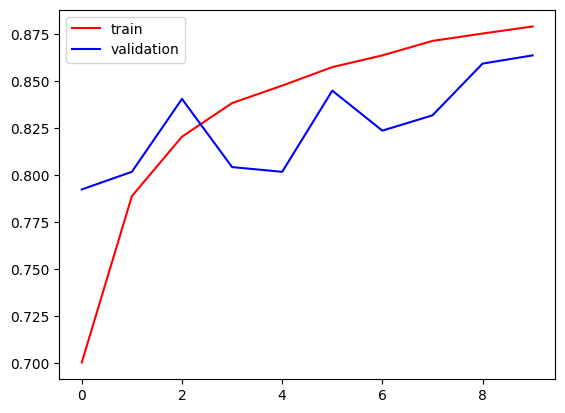

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

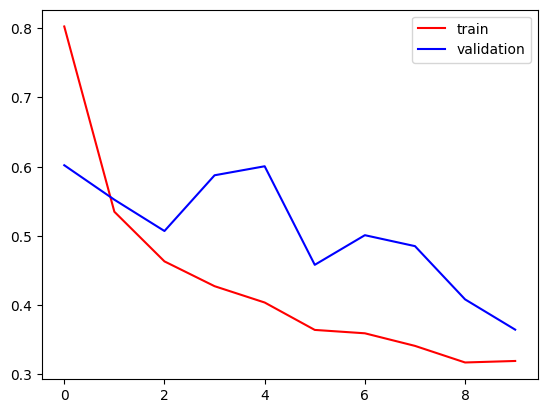

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
model.save('brain_tumor_classifier.keras')

In [ ]:
import os

print(os.listdir())

['.config', 'best_model.keras', 'brain_tumor_classifier.keras', 'brain-tumor-mri-dataset', 'sample_data']


In [ ]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
class_indices = train_generator.class_indices

import json

with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

In [ ]:
from google.colab import files

files.download('brain_tumor_classifier.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download('brain_tumor_classifier.keras')
files.download('class_indices.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>